In [1]:
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.measure import label, regionprops, regionprops_table
import math

import sys
sys.path.append('../src')
from utils import smooth_curve
from Plume import plume_dataset
from Viz import show_images, create_axes_grid
from Velocity import VelocityCalculator

<KeysViewHDF5 ['1-BaTiO3', '1-BaTiO3_Pre']>


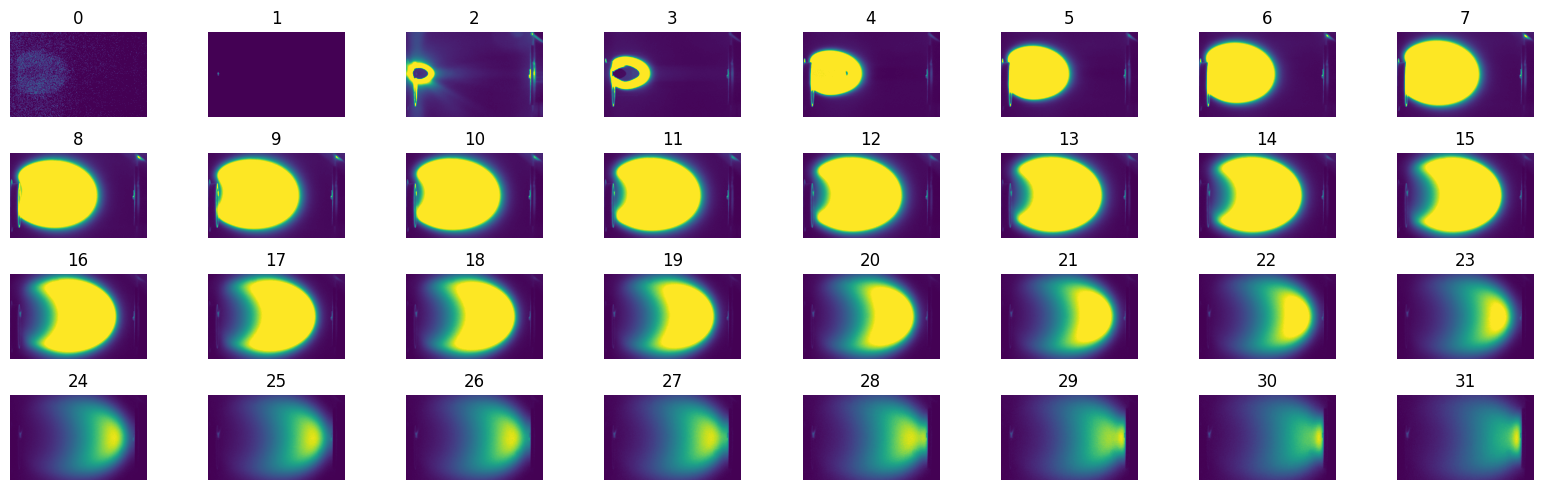

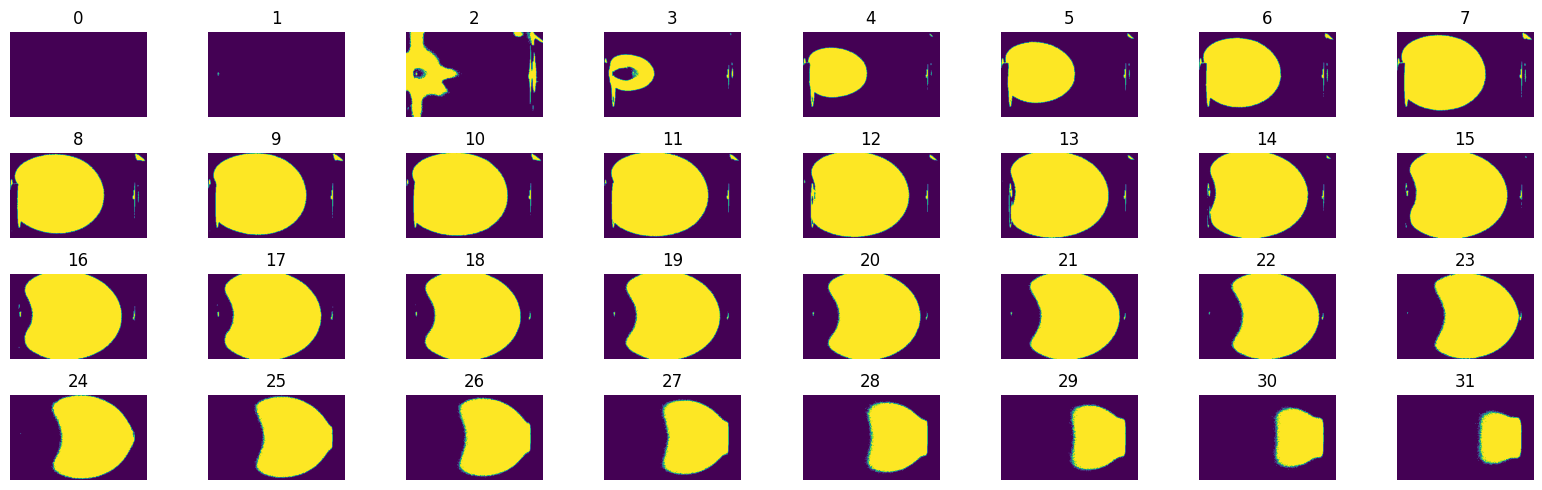

In [2]:
plume_ds = plume_dataset(file_path='../datasets/LYW152_YichenGuo_JulianGoddy_03072024.h5', group_name='PLD_Plumes')
plume_ds.show_dataset_name()
plumes = plume_ds.load_plumes('1-BaTiO3')

plume = plumes[0][:32]
show_images(plume, img_per_row=8)

plume_binary = np.copy(plume)
for i in range(len(plume_binary)):
    _, plume_binary[i] = cv2.threshold(plume_binary[i], 50, 255, cv2.THRESH_BINARY)

show_images(plume_binary, img_per_row=8)

In [13]:
threshold = 50
areas = np.zeros(plumes.shape)
areas_filled = np.zeros(plumes.shape)
front_ends = np.zeros((plumes.shape[0], 2))

for i in tqdm(range(plumes.shape[0])):
    for j in range(plumes[i].shape[1]):
        frame = plumes[i, j]
        
        _, plume_binary = cv2.threshold(frame, threshold, 255, cv2.THRESH_BINARY)
        label_img = label(plume_binary)
        regions = regionprops(label_img)
        sorted_regions = sorted(regions, key=lambda x: x.area, reverse=True)

        if len(sorted_regions) == 0:
            continue
        areas[i, j] = sorted_regions[0].area
        areas_filled[i, j] = sorted_regions[0].filled_area
        front_ends[i, j] = sorted_regions[0].centroid

  0%|          | 0/173 [00:00<?, ?it/s]


ValueError: setting an array element with a sequence.

In [21]:
import cv2
_, image_binary = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)

# Sample binary image
# image_binary = ...

# Find connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(image_binary)

# The 'stats' array has the following structure for each label:
# [x, y, width, height, area]
# We can extract the area information from it
areas = stats[:, -1]

# Print the areas of all connected components
print("Areas of connected components:", areas)

# If you want to exclude the background component, which is usually label 0
areas_without_background = areas[1:]
print("Areas of connected components excluding background:", areas_without_background)

Areas of connected components: [71701 28277     1     1     1     1     1     1     1     1     1     1
     1     1     1     1     1     1     1     1     1     1     1     1]
Areas of connected components excluding background: [28277     1     1     1     1     1     1     1     1     1     1     1
     1     1     1     1     1     1     1     1     1     1     1]


In [26]:
stats

array([[    0,     0,   400,   250, 57098],
       [   94,     6,   237,   237, 42892],
       [   96,    31,     1,     1,     1],
       [   96,    34,     1,     1,     1],
       [  112,    74,     1,     1,     1],
       [  128,   117,     1,     1,     1],
       [  127,   138,     1,     2,     2],
       [  126,   143,     1,     1,     1],
       [   93,   202,     1,     1,     1],
       [   94,   209,     1,     1,     1],
       [  101,   219,     1,     1,     1]], dtype=int32)

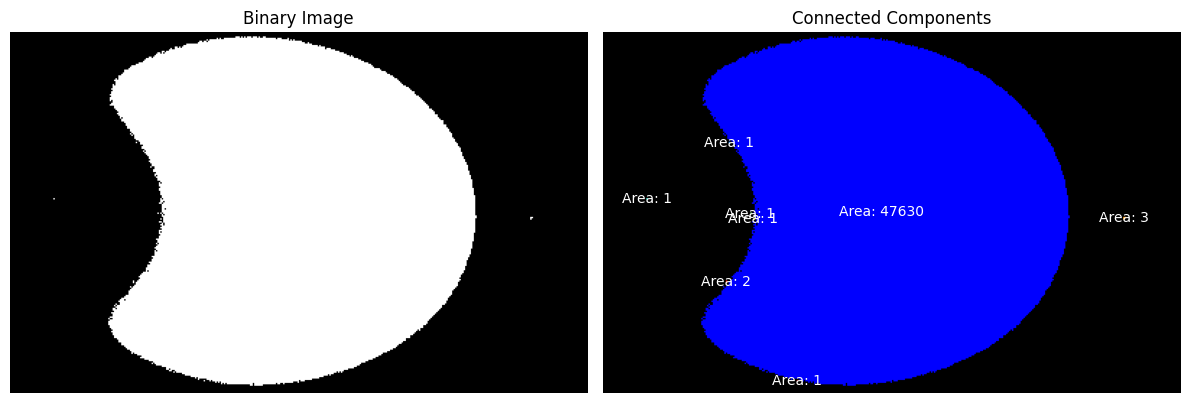

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = plumes[0,17]

# Sample binary image
_, image_binary = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)

# Find connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(image_binary)

areas = stats[:, -1]

# Create a color map for visualization
colors = plt.cm.jet(np.linspace(0, 1, num_labels))

# Create an RGB image for visualization
image_colored = np.zeros((*image_binary.shape, 3), dtype=np.uint8)
for label in range(1, num_labels):  # Skip label 0 (background)
    mask = labels == label
    image_colored[mask] = colors[label][:3] * 255  # Convert color from [0,1] to [0,255]


# Plot the original binary image
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image_binary, cmap='gray')
plt.title('Binary Image')
plt.axis('off')

# Plot the colored connected components with area annotations
plt.subplot(1, 2, 2)
plt.imshow(image_colored)
plt.title('Connected Components')
for label in range(1, num_labels):
    plt.text(centroids[label][0], centroids[label][1], f'Area: {areas[label]}',
             color='white', fontsize=10, ha='center', va='center')
plt.axis('off')

plt.tight_layout()
plt.show()


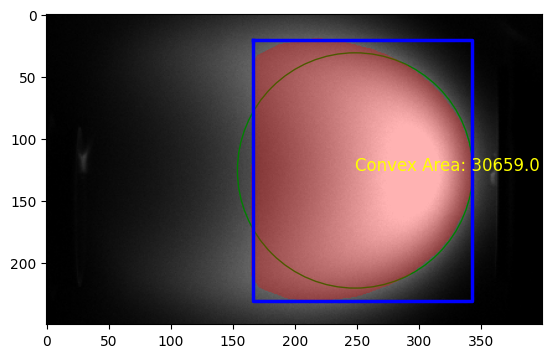

In [20]:
threshold = 100

image = plumes[0,23]
_, image_binary = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)

# Label image and calculate properties
label_img = measure.label(image_binary)
regions = measure.regionprops(label_img)
sorted_regions = sorted(regions, key=lambda x: x.area, reverse=True)

# Create a figure to display the results
fig, ax = plt.subplots()
ax.imshow(image, cmap='gray')

for region in sorted_regions[:1]:
    # Draw the convex hull
    hull = region.convex_image
    bbox = region.bbox
    hull_coords = np.argwhere(hull)
    hull_coords[:, 0] += bbox[0]
    hull_coords[:, 1] += bbox[1]
    ax.plot(hull_coords[:, 1], hull_coords[:, 0], 'r-', linewidth=2, alpha=0.3)

    # Annotate the region's convex area
    ax.text(region.centroid[1], region.centroid[0], f'Convex Area: {region.convex_area}', color='yellow', fontsize=12)

    # Draw a circle with the equivalent diameter
    radius = region.equivalent_diameter / 2
    circle = plt.Circle(region.centroid[::-1], radius, color='green', fill=False)
    ax.add_patch(circle)

    minr, minc, maxr, maxc = region.bbox
    bx = (minc, maxc, maxc, minc, minc)
    by = (minr, minr, maxr, maxr, minr)
    ax.plot(bx, by, '-b', linewidth=2.5)

ax.axis('image')
plt.show()


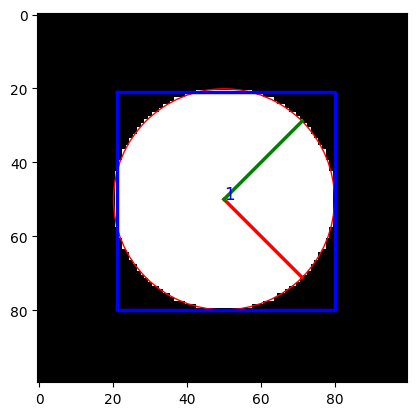

In [7]:
import matplotlib.pyplot as plt
from skimage import measure, draw
import numpy as np

# Sample binary image
image = np.zeros((100, 100), dtype=np.uint8)
rr, cc = draw.disk((50, 50), 30)
image[rr, cc] = 1

# Label image and calculate properties
label_img = measure.label(image)
regions = measure.regionprops(label_img)

# Create a figure to display the results
fig, ax = plt.subplots()
ax.imshow(image, cmap='gray')

for region in regions:
    # Draw a circle with the equivalent diameter
    radius = region.equivalent_diameter / 2
    circle = plt.Circle(region.centroid[::-1], radius, color='red', fill=False)
    ax.add_patch(circle)

    # Draw the major and minor axes of the fitted ellipse
    y0, x0 = region.centroid
    orientation = region.orientation
    x1 = x0 + np.cos(orientation) * 0.5 * region.major_axis_length
    y1 = y0 - np.sin(orientation) * 0.5 * region.major_axis_length
    x2 = x0 - np.sin(orientation) * 0.5 * region.minor_axis_length
    y2 = y0 - np.cos(orientation) * 0.5 * region.minor_axis_length
    ax.plot((x0, x1), (y0, y1), '-r', linewidth=2.5)
    ax.plot((x0, x2), (y0, y2), '-g', linewidth=2.5)

    # Annotate the region's label
    ax.text(x0, y0, str(region.label), color='blue', fontsize=12)

    minr, minc, maxr, maxc = region.bbox
    bx = (minc, maxc, maxc, minc, minc)
    by = (minr, minr, maxr, maxr, minr)
    ax.plot(bx, by, '-b', linewidth=2.5)

ax.axis('image')
plt.show()


In [ ]:
fig, axes = create_axes_grid(n_plots=len(plume_binary), n_per_row=8, plot_height=2)

for ax, image in zip(axes.flatten(), plume_binary):
    label_img = label(image)
    regions = regionprops(label_img)

    sorted_regions = sorted(regions, key=lambda x: x.area, reverse=True)

    ax.imshow(image, cmap=plt.cm.gray)

    max_area = 0
    for props in regions:
        area.append(props.area)
        
        y0, x0 = props.centroid
        ax.plot(x0, y0, '.g', markersize=15)

        minr, minc, maxr, maxc = props.bbox
        bx = (minc, maxc, maxc, minc, minc)
        by = (minr, minr, maxr, maxr, minr)
        ax.plot(bx, by, '-b', linewidth=2.5)

        if props.area > max_area:
            max_area = props.area

    ax.set_title(f'Area: {max_area}')

    # ax.legend()

# ax.axis((0, 600, 600, 0))
plt.show()

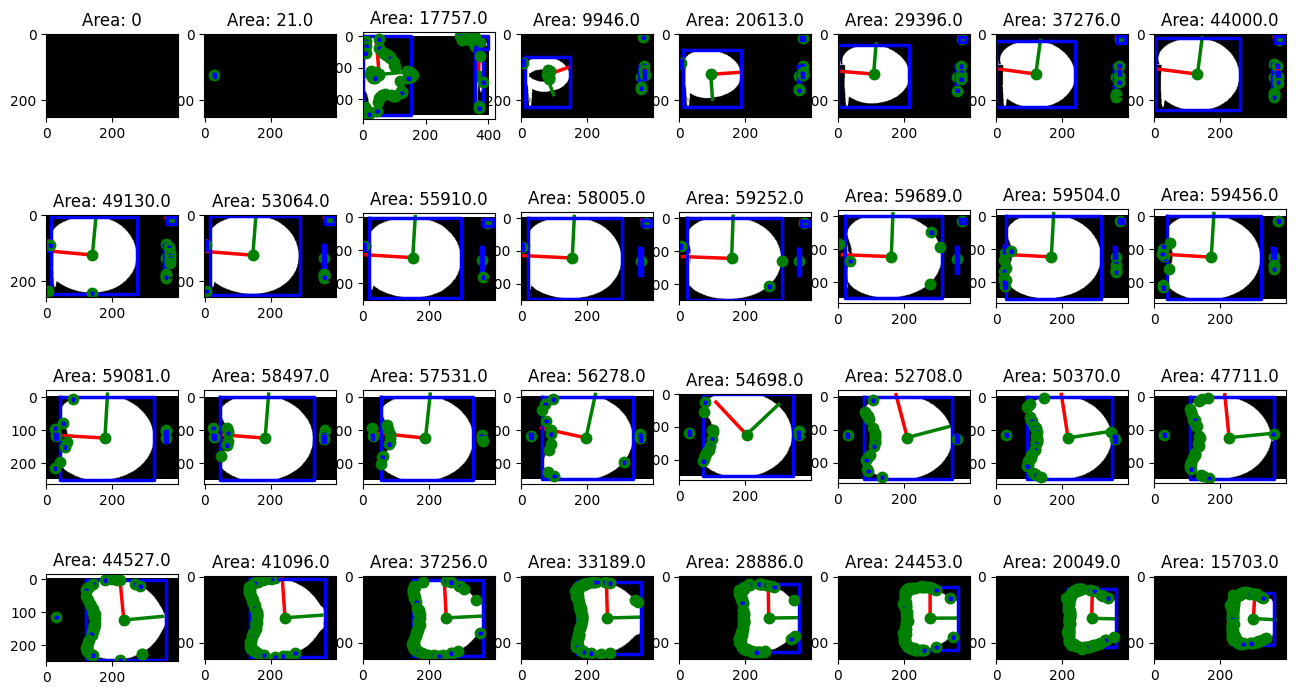

In [6]:
fig, axes = create_axes_grid(n_plots=len(plume_binary), n_per_row=8, plot_height=2)

for ax, image in zip(axes.flatten(), plume_binary):
    label_img = label(image)
    regions = regionprops(label_img)

    ax.imshow(image, cmap=plt.cm.gray)

    max_area = 0
    for props in regions:
        area.append(props.area)
        


        y0, x0 = props.centroid
        # print(props.centroid)
        orientation = props.orientation
        x1 = x0 + math.cos(orientation) * 0.5 * props.axis_minor_length
        y1 = y0 - math.sin(orientation) * 0.5 * props.axis_minor_length
        x2 = x0 - math.sin(orientation) * 0.5 * props.axis_major_length
        y2 = y0 - math.cos(orientation) * 0.5 * props.axis_major_length

        ax.plot((x0, x1), (y0, y1), '-g', linewidth=2.5, label='Minor axis')
        ax.plot((x0, x2), (y0, y2), '-r', linewidth=2.5, label='Major axis')
        ax.plot(x0, y0, '.g', markersize=15)

        minr, minc, maxr, maxc = props.bbox
        bx = (minc, maxc, maxc, minc, minc)
        by = (minr, minr, maxr, maxr, minr)
        ax.plot(bx, by, '-b', linewidth=2.5)

        if props.area > max_area:
            max_area = props.area

    ax.set_title(f'Area: {max_area}')

    # ax.legend()

# ax.axis((0, 600, 600, 0))
plt.show()

In [3]:
from skimage.measure import label, regionprops, regionprops_table
properties = ['area', 'axis_major_length', 'axis_minor_length', 'centroid', 'orientation', 'eccentricity', 'perimeter']
plume_areas, plume_orientations, plume_perimeters, plume_eccentricities = [], [], [], []
for frame in tqdm(plumes[0]):
    props = regionprops_table(frame, properties=properties)
    plume_areas.append(props['area'])
    plume_orientations.append(props['orientation'])
    plume_perimeters.append(props['perimeter'])
    plume_eccentricities.append(props['eccentricity'])

  2%|▏         | 2/128 [00:00<00:38,  3.25it/s]


KeyboardInterrupt: 

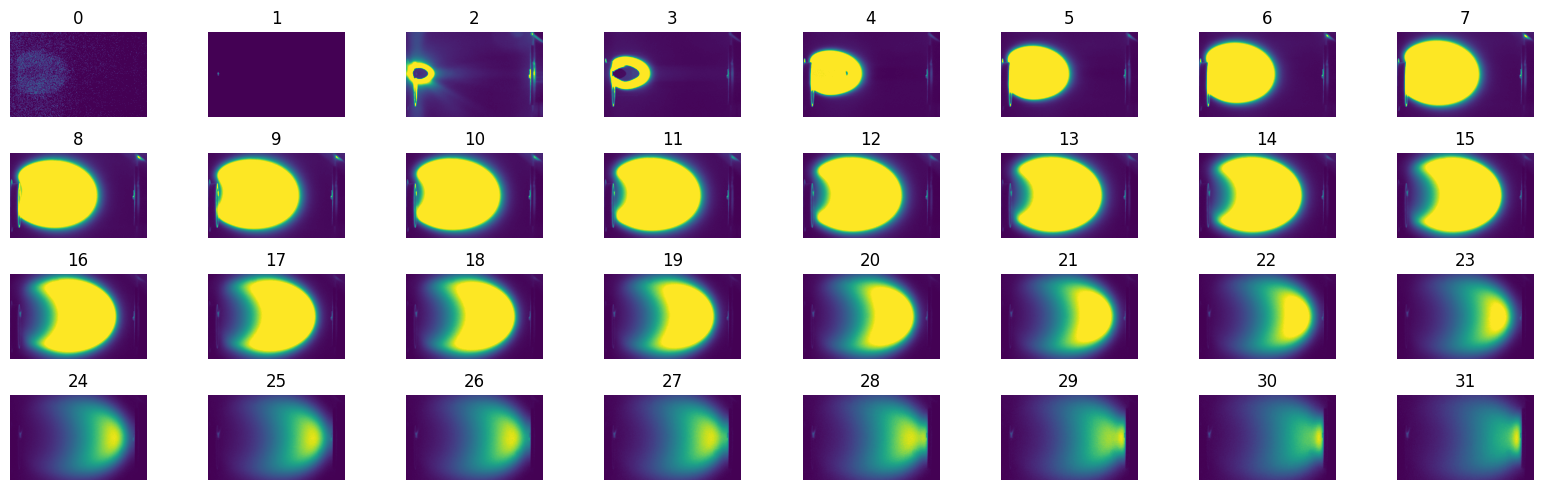

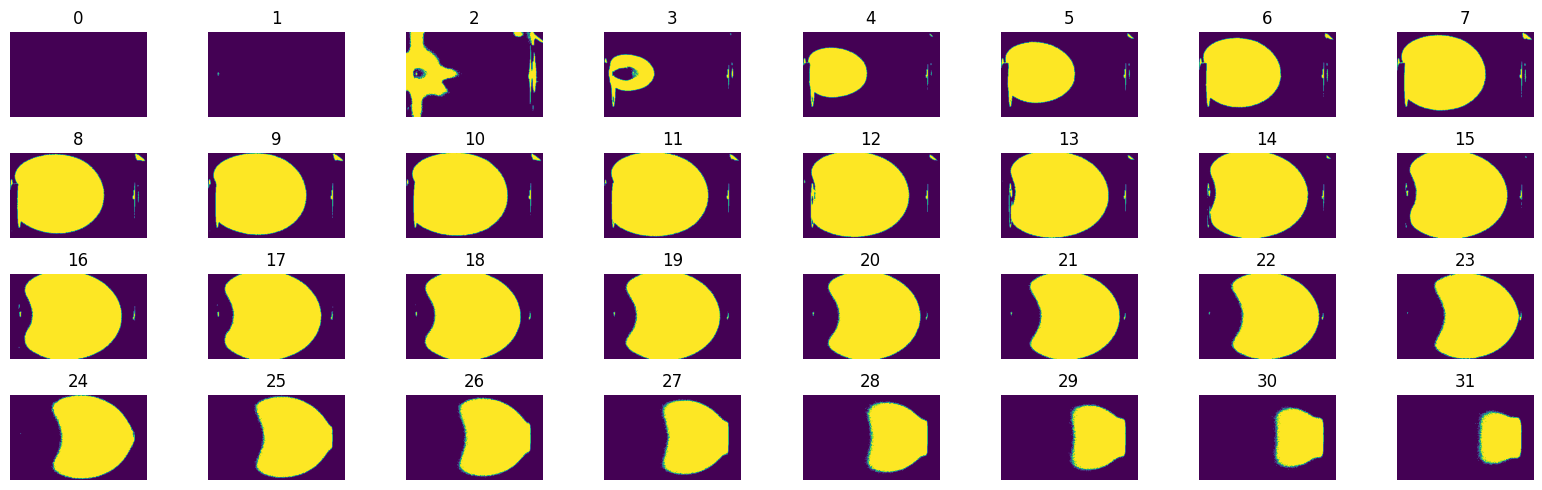

In [14]:
plume = plumes[0][:32]
show_images(plume, img_per_row=8)

plume_binary = np.copy(plume)
for i in range(len(plume_binary)):
    _, plume_binary[i] = cv2.threshold(plume_binary[i], 50, 255, cv2.THRESH_BINARY)

show_images(plume_binary, img_per_row=8)

In [29]:
regions[0]

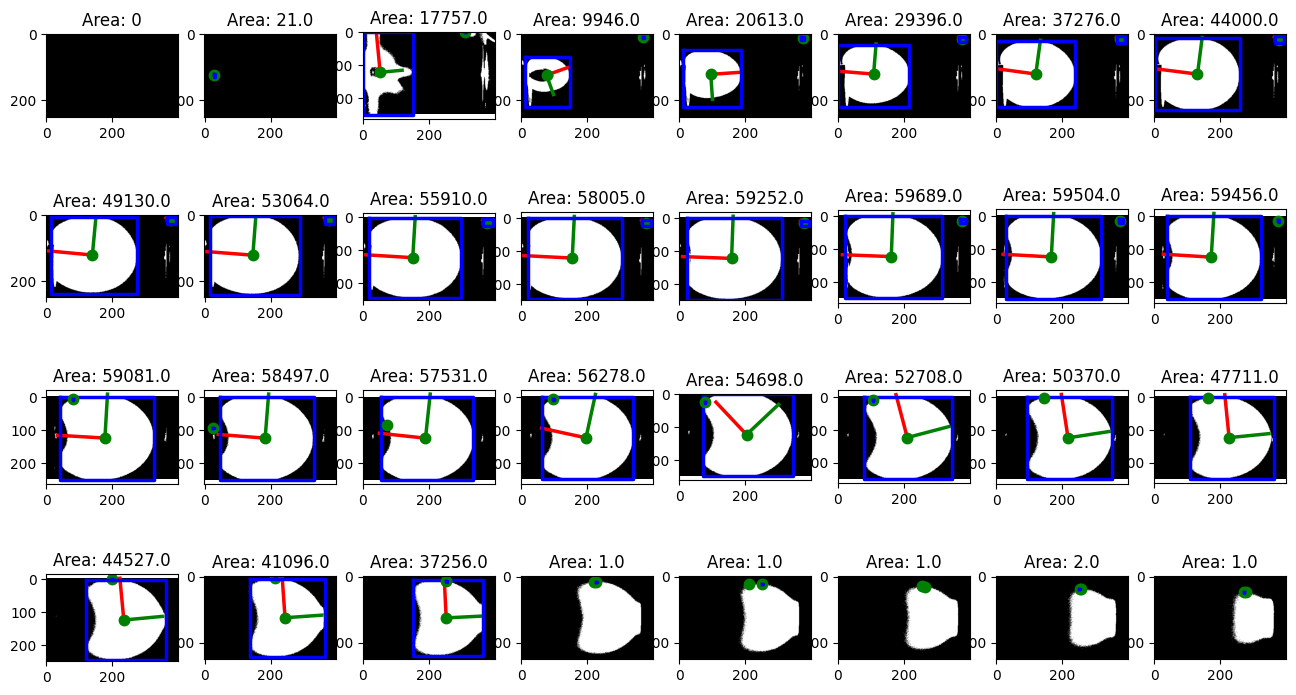

In [23]:
fig, axes = create_axes_grid(n_plots=len(plume_binary), n_per_row=8, plot_height=2)

for ax, image in zip(axes.flatten(), plume_binary):
    label_img = label(image)
    regions = regionprops(label_img)

    ax.imshow(image, cmap=plt.cm.gray)

    max_area = 0
    for props in regions[:2]:
        y0, x0 = props.centroid
        # print(props.centroid)
        orientation = props.orientation
        x1 = x0 + math.cos(orientation) * 0.5 * props.axis_minor_length
        y1 = y0 - math.sin(orientation) * 0.5 * props.axis_minor_length
        x2 = x0 - math.sin(orientation) * 0.5 * props.axis_major_length
        y2 = y0 - math.cos(orientation) * 0.5 * props.axis_major_length

        ax.plot((x0, x1), (y0, y1), '-g', linewidth=2.5, label='Minor axis')
        ax.plot((x0, x2), (y0, y2), '-r', linewidth=2.5, label='Major axis')
        ax.plot(x0, y0, '.g', markersize=15)

        minr, minc, maxr, maxc = props.bbox
        bx = (minc, maxc, maxc, minc, minc)
        by = (minr, minr, maxr, maxr, minr)
        ax.plot(bx, by, '-b', linewidth=2.5)

        if props.area > max_area:
            max_area = props.area

    ax.set_title(f'Area: {max_area}')

    # ax.legend()

# ax.axis((0, 600, 600, 0))
plt.show()

In [ ]:

label_img = label(image)
regions = regionprops(label_img)

fig, ax = plt.subplots()
ax.imshow(image, cmap=plt.cm.gray)

for props in regions:
    y0, x0 = props.centroid
    orientation = props.orientation
    x1 = x0 + math.cos(orientation) * 0.5 * props.axis_minor_length
    y1 = y0 - math.sin(orientation) * 0.5 * props.axis_minor_length
    x2 = x0 - math.sin(orientation) * 0.5 * props.axis_major_length
    y2 = y0 - math.cos(orientation) * 0.5 * props.axis_major_length

    ax.plot((x0, x1), (y0, y1), '-r', linewidth=2.5)
    ax.plot((x0, x2), (y0, y2), '-r', linewidth=2.5)
    ax.plot(x0, y0, '.g', markersize=15)

    minr, minc, maxr, maxc = props.bbox
    bx = (minc, maxc, maxc, minc, minc)
    by = (minr, minr, maxr, maxr, minr)
    ax.plot(bx, by, '-b', linewidth=2.5)

# ax.axis((0, 600, 600, 0))
plt.show()

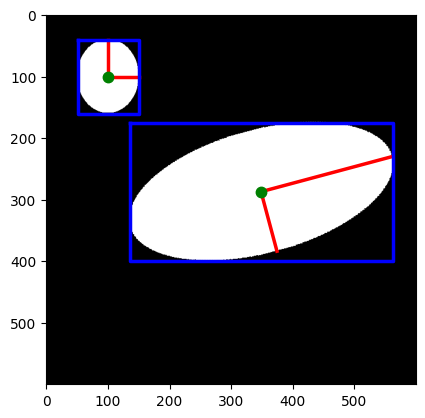

In [21]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skimage.draw import ellipse
from skimage.measure import label, regionprops, regionprops_table
from skimage.transform import rotate


image = np.zeros((600, 600))

rr, cc = ellipse(300, 350, 100, 220)
image[rr, cc] = 1

image = rotate(image, angle=15, order=0)

rr, cc = ellipse(100, 100, 60, 50)
image[rr, cc] = 1

label_img = label(image)
regions = regionprops(label_img)

fig, ax = plt.subplots()
ax.imshow(image, cmap=plt.cm.gray)

for props in regions:
    y0, x0 = props.centroid
    orientation = props.orientation
    x1 = x0 + math.cos(orientation) * 0.5 * props.axis_minor_length
    y1 = y0 - math.sin(orientation) * 0.5 * props.axis_minor_length
    x2 = x0 - math.sin(orientation) * 0.5 * props.axis_major_length
    y2 = y0 - math.cos(orientation) * 0.5 * props.axis_major_length

    ax.plot((x0, x1), (y0, y1), '-r', linewidth=2.5)
    ax.plot((x0, x2), (y0, y2), '-r', linewidth=2.5)
    ax.plot(x0, y0, '.g', markersize=15)

    minr, minc, maxr, maxc = props.bbox
    bx = (minc, maxc, maxc, minc, minc)
    by = (minr, minr, maxr, maxr, minr)
    ax.plot(bx, by, '-b', linewidth=2.5)

# ax.axis((0, 600, 600, 0))
plt.show()

In [15]:
plume_areas = np.array

[array([1.2574e+04, 1.8630e+03, 9.6000e+01, 1.0000e+00]),
 array([1.107e+03, 3.700e+01, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 2.000e+00, 1.000e+00, 1.000e+00, 3.000e+00, 1.000e+00,
        1.000e+00, 2.000e+00, 1.000e+00, 1.000e+00, 2.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 3.000e+00, 2.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 3.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 2.000e+00, 2.000e+00, 1.000e+00, 1.000e+00, 2.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00]),
 array([1.000e+00, 6.000e+00, 3.600e+01, 1.230e+02, 2.640e+02, 6.510e+02,
        1.710e+03, 3.111e+03, 4.550e+03, 4.901e+03, 4.552e+03, 4.059e+03,
        3.876e+03, 3.890e+03, 4.028e+03, 3.863e+03, 3.763e+03, 3.588e+03,
        3.248e+03, 3.193e+03, 2.906e+03, 2.647e+03, 2.382e+03, 1.978e+03,
        1.781e+03, 1.637e+03, 1.420e+03, 1.276e+03, 1.214e+03, 1.179e+03,
        1.067e+03, 1.093e+03, 9.830e+02, 8.840e+02, 8.970e+02, 9.030e+02,


ValueError: Input could not be cast to an at-least-1D NumPy array

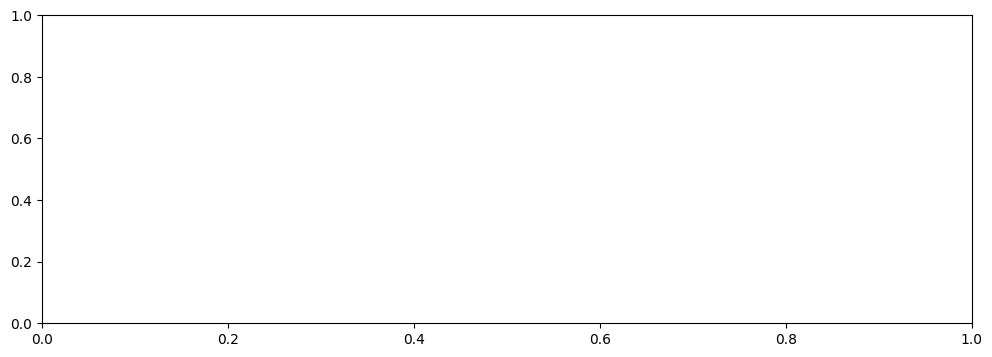

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
plt.plot(plume_areas)
plt.show()

In [2]:
plume_ds = plume_dataset(file_path='../datasets/LYW152_YichenGuo_JulianGoddy_03072024.h5', group_name='PLD_Plumes')
plume_ds.show_dataset_name()
plumes = plume_ds.load_plumes('1-BaTiO3')

position_range = (34, 367)
start_position = (29, 126)
threshold = 100
time_interval = 500e-9 # 500ns
V = VelocityCalculator(time_interval, position_range, start_position, threshold=50)
time, plume_positions, plume_distances, plume_velocities = V.velocity_one_func(plumes)

<KeysViewHDF5 ['1-BaTiO3', '1-BaTiO3_Pre']>


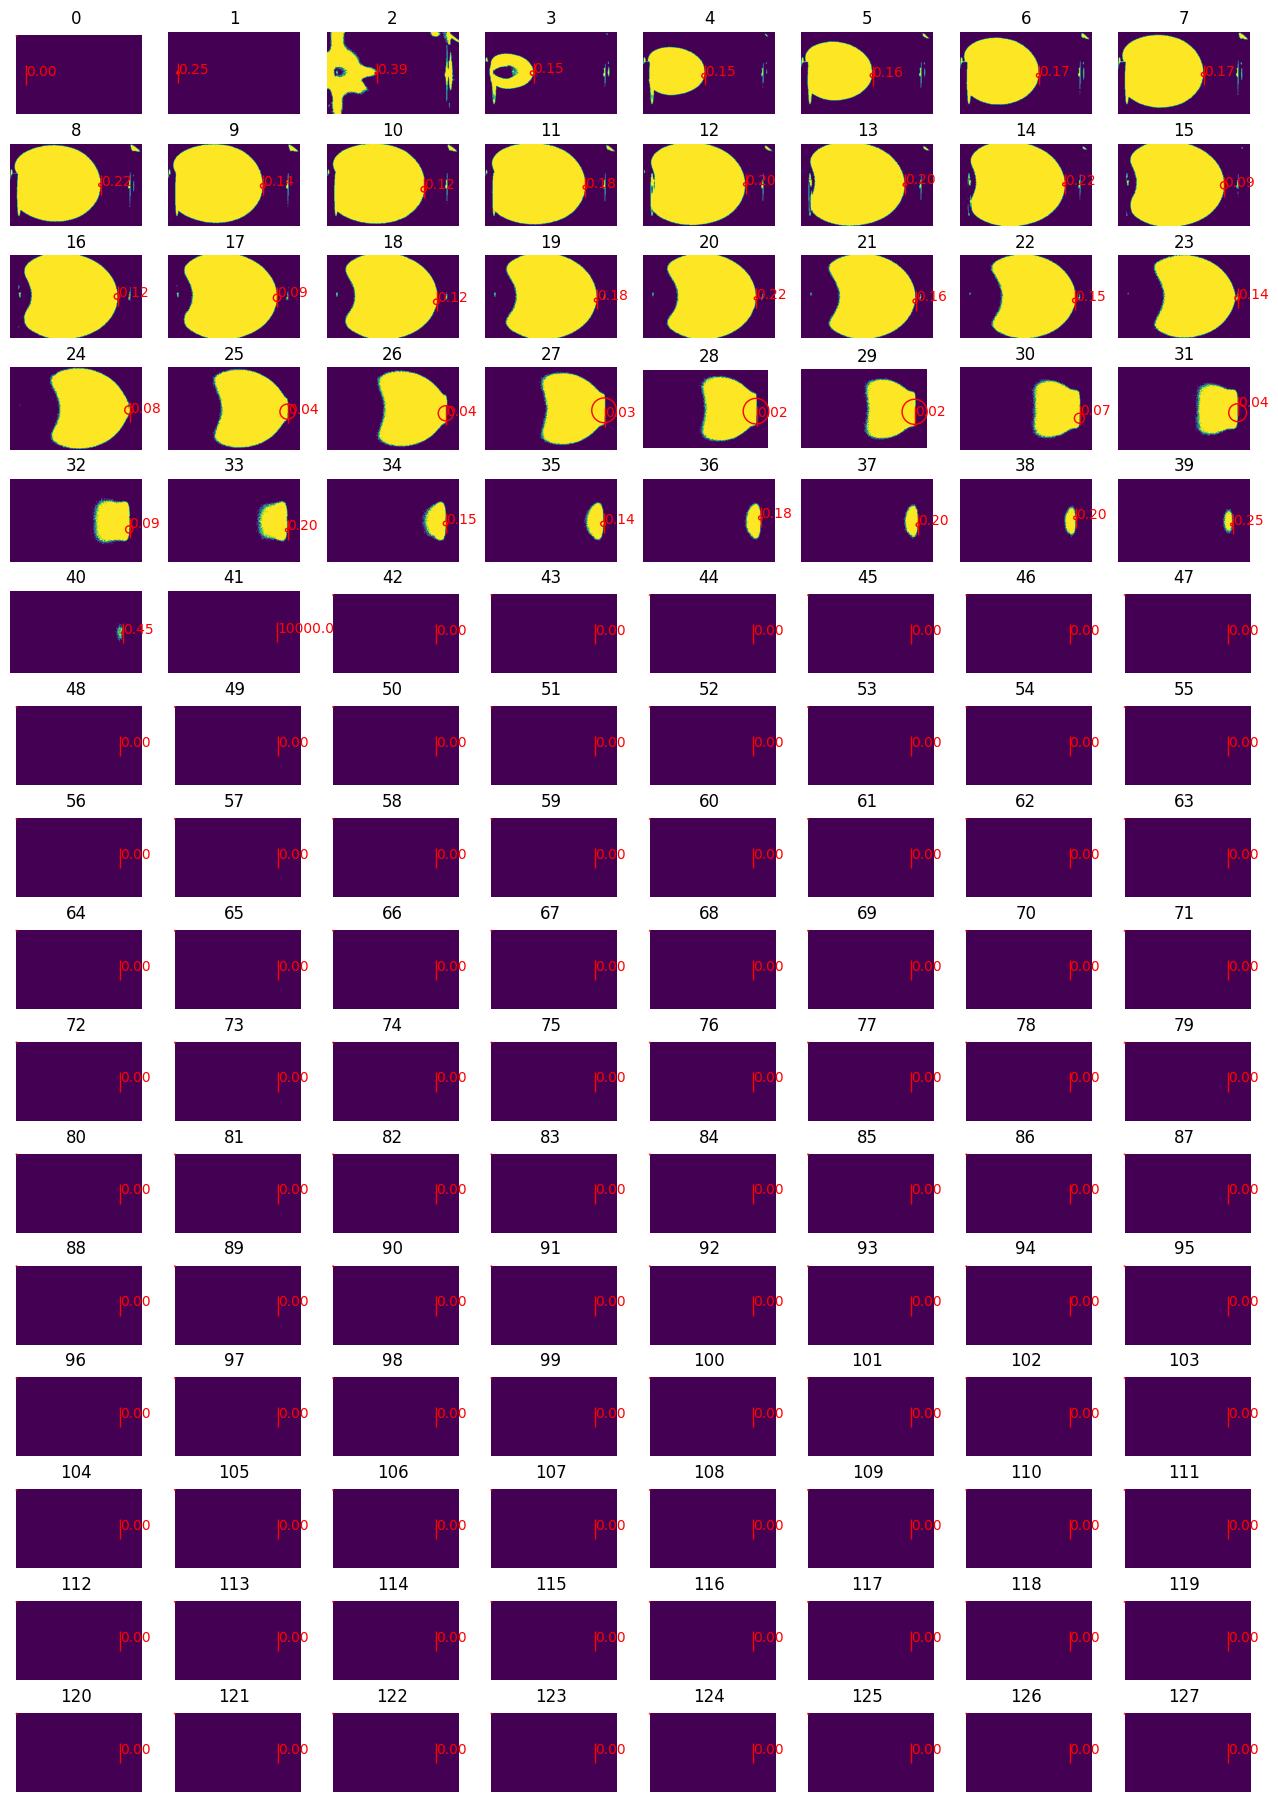

In [3]:
plume_position = plume_positions[0]
plume = plumes[0]

curvatures, centers, radii = V.calculate_plume_curvature(plume, edge_width=5)

titles = np.arange(0, plume_position.shape[0])
fig, axes = create_axes_grid(len(plume), n_per_row=8, plot_height=1.4)
# fig, axes = plt.subplots(5, 8, figsize=(16, 10))
for i, ax in enumerate(axes.flatten()):

    _, mask = cv2.threshold(plume[i], 50, 255, cv2.THRESH_BINARY)

    x, y = plume_position[i]
    ax.imshow(mask)
    ax.plot(x, y, 'r|', markersize=15)

    circle = plt.Circle(centers[i], radii[i], color='r', fill=False)
    ax.add_patch(circle)
    ax.text(x, y, f'{curvatures[i]:.2f}', color='red')
    ax.axis('off')
    ax.set_title(titles[i])
plt.show()

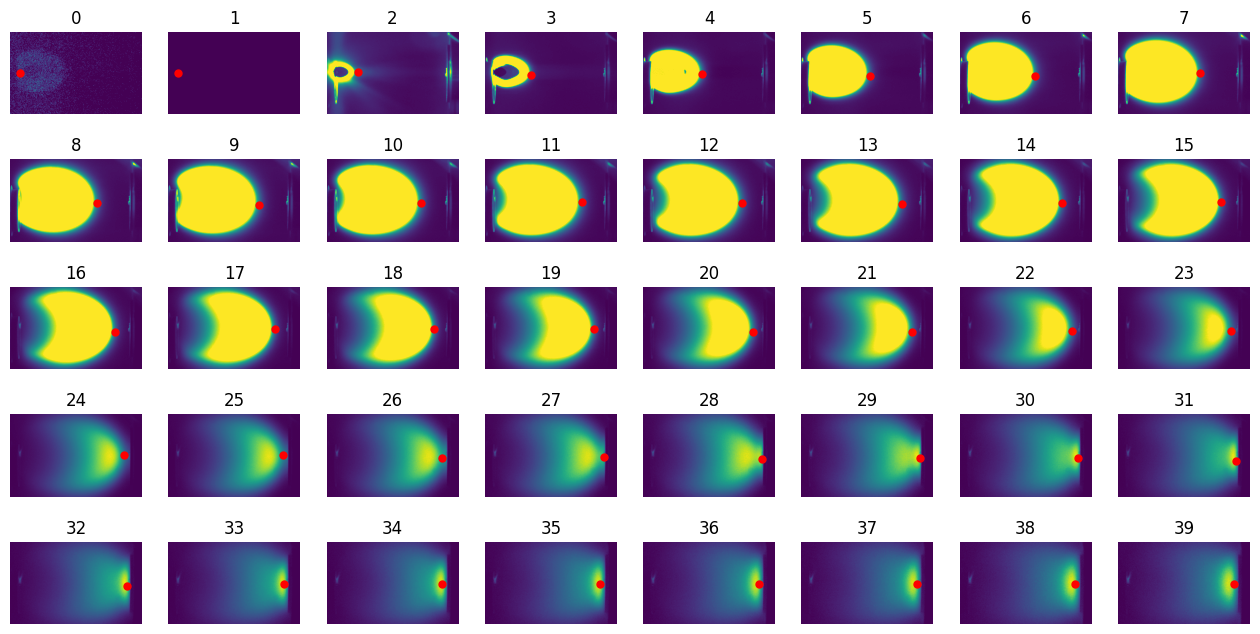

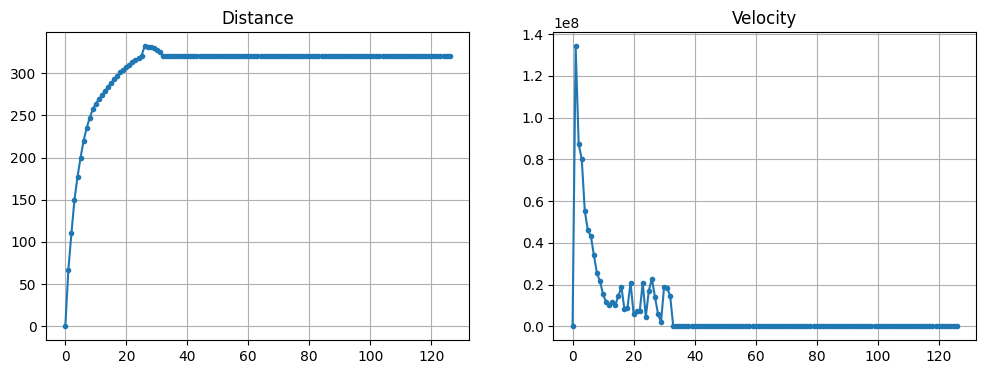

In [3]:
index = 0
V.visualize_plume_positions(plumes[index][:40], plume_positions[index][:40], label_time=False)
V.visualize_distance_velocity(plume_distances[index], plume_velocities[index], index_time=False)